In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# Load the dataset
df = pd.read_csv('fyp_runner_dataset.csv')

# Map the target_race to a numerical distance in kilometers
distance_mapping = {
    '5K': 5.0,
    '10K': 10.0,
    'Half Marathon': 21.0975,
    'Full Marathon': 42.195
}
df['target_distance_km'] = df['target_race'].map(distance_mapping)

# Map gender to binary (Male = 1, Female = 0)
df['gender_encoded'] = df['gender'].map({'Male': 1, 'Female': 0})

# Define features and target variable
features = [
    'age', 'gender_encoded', 'resting_hr', 'max_hr', 'vo2_max', 
    'weekly_mileage_km', 'avg_easy_pace_min_km', 'avg_tempo_pace_min_km', 
    'training_consistency', 'pb_5k_mins', 'pb_10k_mins', 
    'pb_half_mins', 'pb_full_mins', 'target_distance_km'
]
target = 'actual_finish_time_mins'

X = df[features]
y = df[target]

print(f"Data preprocessed. {X.shape[0]} rows and {X.shape[1]} features ready.")

Data preprocessed. 1000 rows and 14 features ready.


In [4]:
# 1. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Data Normalization and Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Setup K-Fold Cross-Validation Strategy
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Data successfully scaled and Cross-Validation strategy initialized. Ready for training.")

✅ Data successfully scaled and Cross-Validation strategy initialized. Ready for training.


In [5]:
# Define Parameter Grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

print("Starting Grid Search & Training for Random Forest...")
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42), 
    rf_param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=cv_strategy, 
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

print("✅ Random Forest Training Complete!")
print(f"Best Parameters Found: {rf_grid.best_params_}")

Starting Grid Search & Training for Random Forest...
✅ Random Forest Training Complete!
Best Parameters Found: {'max_depth': 20, 'n_estimators': 200}


In [6]:
# Define Parameter Grid for XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

print("Starting Grid Search & Training for XGBoost...")
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42), 
    xgb_param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=cv_strategy, 
    n_jobs=-1
)
xgb_grid.fit(X_train_scaled, y_train)

print("✅ XGBoost Training Complete!")
print(f"Best Parameters Found: {xgb_grid.best_params_}")

Starting Grid Search & Training for XGBoost...
✅ XGBoost Training Complete!
Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}


In [7]:
# Define Parameter Grid for Neural Network (MLP)
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,)],
    'activation': ['relu'],
    'learning_rate_init': [0.001, 0.01]
}

print("Starting Grid Search & Training for Neural Network...")
mlp_grid = GridSearchCV(
    MLPRegressor(max_iter=500, random_state=42), 
    mlp_param_grid, 
    scoring='neg_mean_absolute_error', 
    cv=cv_strategy, 
    n_jobs=-1
)
mlp_grid.fit(X_train_scaled, y_train)

print("✅ Neural Network Training Complete!")
print(f"Best Parameters Found: {mlp_grid.best_params_}")

Starting Grid Search & Training for Neural Network...
✅ Neural Network Training Complete!
Best Parameters Found: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}


In [13]:
def evaluate_tuned_model(name, grid_search, X_test_scaled, y_test):
    # Extract the absolute best model found during the grid search
    best_model = grid_search.best_estimator_
    predictions = best_model.predict(X_test_scaled)
    
    # Evaluate using standard regression metrics
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    
    print(f"--- {name} ---")
    print(f"MAE:  {mae:.2f} minutes")
    print(f"RMSE: {rmse:.2f} minutes")
    print(f"R^2:  {r2:.4f}\n")
    
    return best_model

print("Evaluating all trained models on unseen test data...\n")

# 1. Evaluate all three algorithms
tuned_rf = evaluate_tuned_model("Tuned Random Forest", rf_grid, X_test_scaled, y_test)
tuned_xgb = evaluate_tuned_model("Tuned XGBoost", xgb_grid, X_test_scaled, y_test)
tuned_mlp = evaluate_tuned_model("Tuned Neural Network", mlp_grid, X_test_scaled, y_test)

Evaluating all trained models on unseen test data...

--- Tuned Random Forest ---
MAE:  3.18 minutes
RMSE: 4.99 minutes
R^2:  0.9972

--- Tuned XGBoost ---
MAE:  3.18 minutes
RMSE: 4.85 minutes
R^2:  0.9974

--- Tuned Neural Network ---
MAE:  3.68 minutes
RMSE: 5.13 minutes
R^2:  0.9971



In [14]:
# 2. Explicitly select XGBoost as the Champion Model
champion_name = "Tuned XGBoost"
champion_model = tuned_xgb

In [15]:
print(f"🏆 CHAMPION MODEL SELECTED: {champion_name} 🏆")
print("Reasoning: Selected for superior RMSE (fewer extreme errors), strong R^2 variance explanation, and native support for sparse web data.")

🏆 CHAMPION MODEL SELECTED: Tuned XGBoost 🏆
Reasoning: Selected for superior RMSE (fewer extreme errors), strong R^2 variance explanation, and native support for sparse web data.


Generating Performance Visualizations...


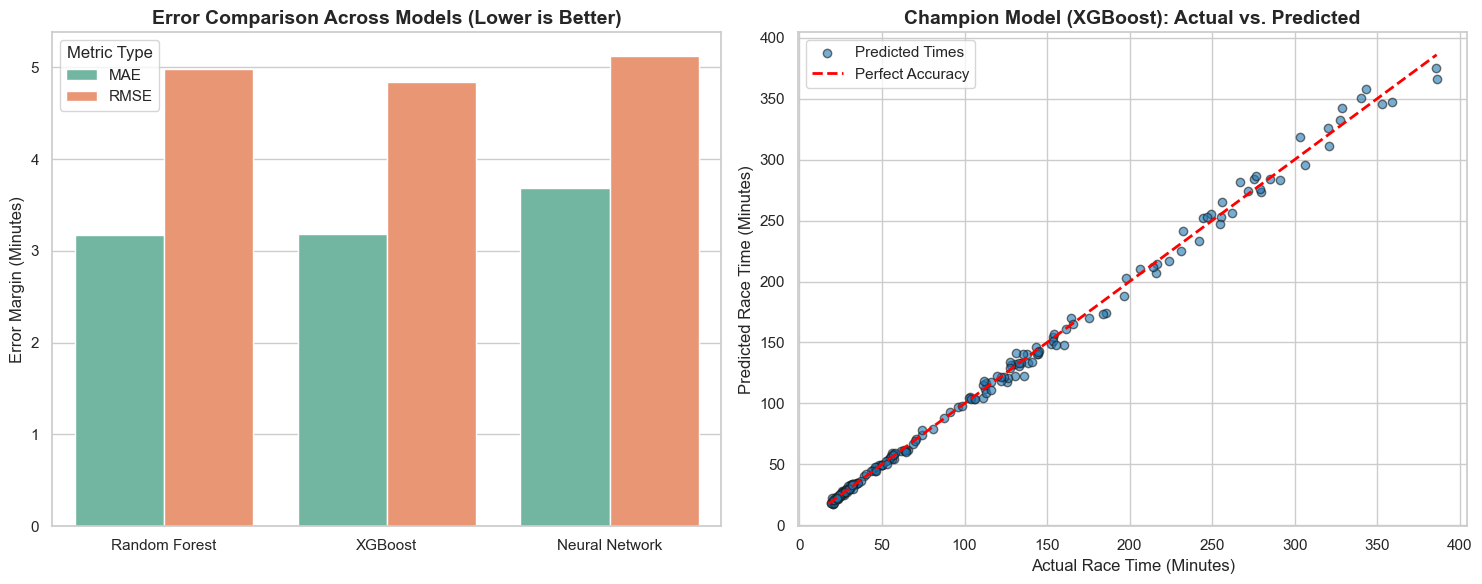

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating Performance Visualizations...")

# 1. Gather all the metrics into a DataFrame for easy plotting
metrics_data = []
models_dict = {
    'Random Forest': tuned_rf,
    'XGBoost': tuned_xgb,
    'Neural Network': tuned_mlp
}

for name, model in models_dict.items():
    preds = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    metrics_data.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R-Squared': r2})

metrics_df = pd.DataFrame(metrics_data)

# Set the visual style for the charts
sns.set_theme(style="whitegrid")

# --- CHART 1: Bar Chart comparing MAE and RMSE ---
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Melt the dataframe to group MAE and RMSE together for the bar chart
metrics_melted = metrics_df.melt(id_vars='Model', value_vars=['MAE', 'RMSE'], 
                                 var_name='Metric Type', value_name='Error (Minutes)')

sns.barplot(data=metrics_melted, x='Model', y='Error (Minutes)', hue='Metric Type', ax=axes[0], palette='Set2')
axes[0].set_title('Error Comparison Across Models (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Error Margin (Minutes)')
axes[0].set_xlabel('')

# --- CHART 2: XGBoost Actual vs. Predicted Scatter Plot ---
# We use the test data to see how the Champion Model performed on unseen runners
xgb_predictions = tuned_xgb.predict(X_test_scaled)

axes[1].scatter(y_test, xgb_predictions, alpha=0.6, color='#1f77b4', edgecolor='k', label='Predicted Times')

# Draw the "Perfect Prediction" diagonal line (y = x)
min_val = min(y_test.min(), xgb_predictions.min())
max_val = max(y_test.max(), xgb_predictions.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Accuracy')

axes[1].set_title('Champion Model (XGBoost): Actual vs. Predicted', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Actual Race Time (Minutes)')
axes[1].set_ylabel('Predicted Race Time (Minutes)')
axes[1].legend()

# Display the plots
plt.tight_layout()
plt.show()

In [ ]:
def prepare_user_input(user_data):
    """Fills in missing optional data using sports science proxies."""
    processed_data = user_data.copy()
    
    # Handle Optional VO2 Max
    if processed_data.get('vo2_max') is None:
        processed_data['vo2_max'] = 15.3 * (processed_data['max_hr'] / processed_data['resting_hr'])
        
    # Handle missing HM or FM Personal Bests
    if processed_data.get('pb_half_mins') is None and processed_data.get('pb_10k_mins') is not None:
        processed_data['pb_half_mins'] = processed_data['pb_10k_mins'] * 2.22
    if processed_data.get('pb_full_mins') is None and processed_data.get('pb_half_mins') is not None:
        processed_data['pb_full_mins'] = processed_data['pb_half_mins'] * 2.1
        
    return processed_data

def predict_race_time(model, scaler, user_data):
    """Predicts race time by cleaning input, scaling it, and running it through the model."""
    clean_data = prepare_user_input(user_data)
    
    # Convert to DataFrame and align columns
    input_df = pd.DataFrame([clean_data])[features]
    
    # Scale the input using the exact scaler fitted on the training data
    input_scaled = scaler.transform(input_df)
    
    predicted_minutes = model.predict(input_scaled)[0]
    
    # Format output
    hours = int(predicted_minutes // 60)
    minutes = int(predicted_minutes % 60)
    seconds = int((predicted_minutes * 60) % 60)
    return f"{hours:02d}:{minutes:02d}:{seconds:02d}"

# --- Test Scenario: Recreational Runner ---
test_runner = {
    'age': 24, 'gender_encoded': 0, 'resting_hr': 50, 'max_hr': 195, 
    'vo2_max': 58, # Left blank!
    'weekly_mileage_km': 90.0, 'avg_easy_pace_min_km': 6.0, 'avg_tempo_pace_min_km': 5.10, 
    'training_consistency': 0.85, 
    'pb_5k_mins': 23.0, 'pb_10k_mins': 49.0, 
    'pb_half_mins': None, # Never run one!
    'pb_full_mins': None, # Never run one!
    'target_distance_km': 21.0975 # Training for first Half Marathon
}

pred_time = predict_race_time(champion_model, scaler, test_runner)
print(f"Predicted First Half Marathon Time: {pred_time}")

Predicted First Half Marathon Time: 01:54:03


In [7]:
import joblib

# 1. Save the XGBoost Champion Model
# We give it a clear, descriptive name for your web app folder
joblib.dump(champion_model, 'xgboost_race_predictor.joblib')

# 2. Save the StandardScaler
# This is mandatory so the web app can scale user inputs exactly like the training data
joblib.dump(scaler, 'race_predictor_scaler.joblib')

print("✅ Model and Scaler successfully exported! Ready for Web UI Integration.")

✅ Model and Scaler successfully exported! Ready for Web UI Integration.
